5097it [00:17, 291.02it/s, +400 | bound: 34 | nc: 1 | ncall: 215421 | eff(%):  2.556 | loglstar:   -inf < -12.182 <    inf | logz: -24.715 +/-    nan | dlogz:  0.001 >  0.500]


  $\gamma_g$  =  0.225  +0.300 / -0.121
  $Z_{g,10}$  =  8.687  +0.407 / -0.167
       $P_b$  =  0.285  +0.414 / -0.200
       $Y_b$  =  8.300  +0.158 / -0.504
       $V_b$  =  0.113  +1.225 / -0.096

Galaxies with q_inlier < 0.5 (likely outliers):
    logmstellar  Z_dir_gen  q_inlier
18     8.960445       8.13  0.232598
19     7.828645       7.84  0.236835
23     7.680879       7.86  0.164156


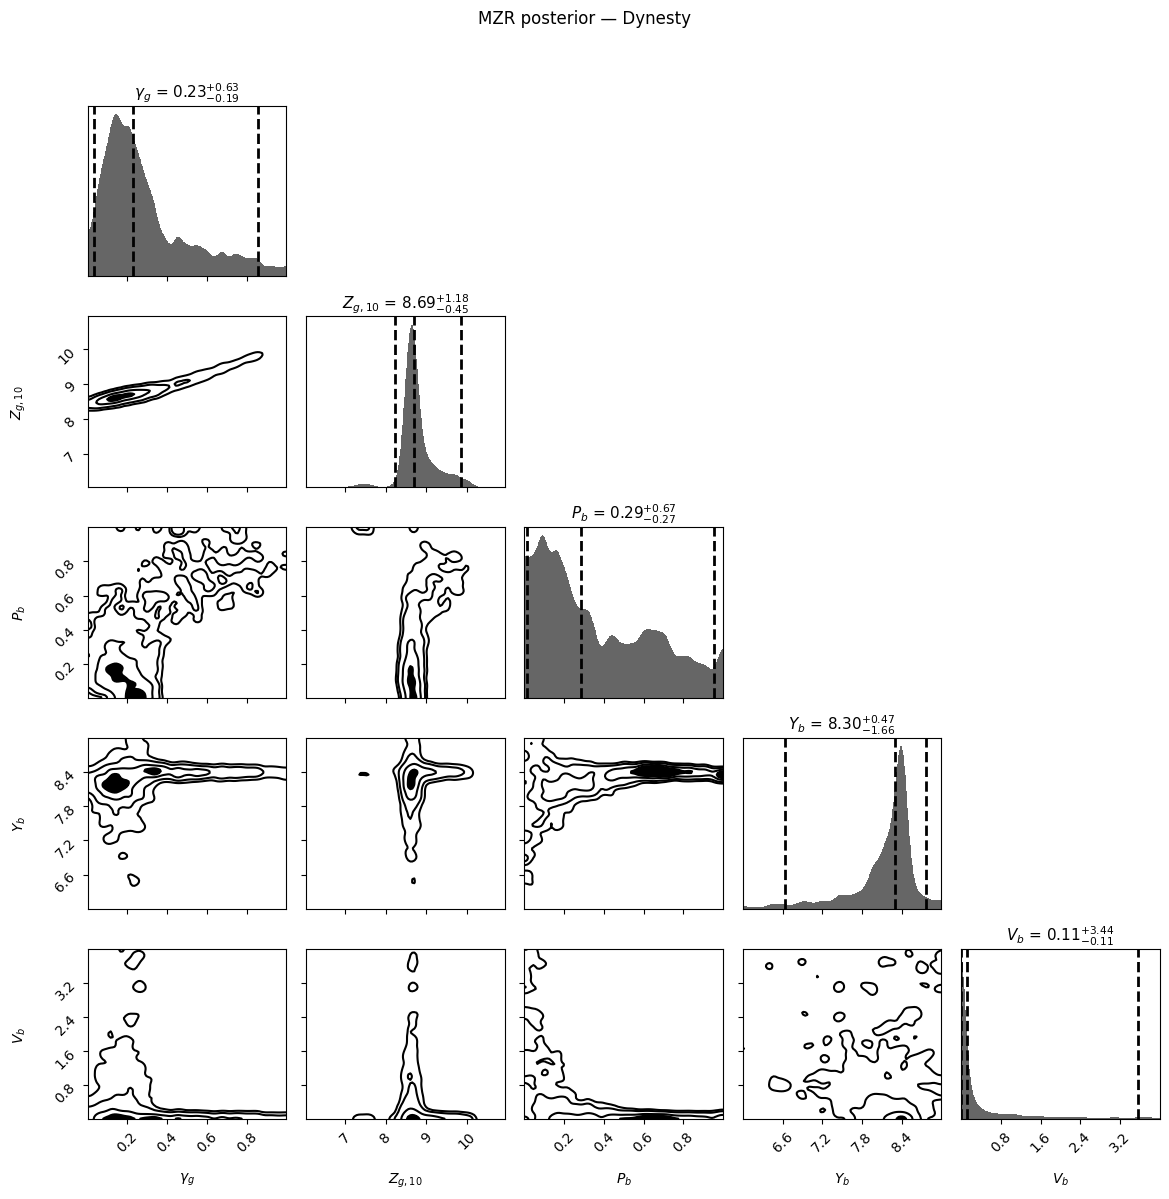

In [9]:
"""
Bayesian fitting of the Mass-Metallicity Relation (MZR) using Dynesty.

Model (Equation 2):
    12 + log(O/H) = gamma_g * [log(M_star/M_sun) - 10] + Z_g10

Two modes:
    A) No outlier rejection   -> ln_likelihood_normal  (2 parameters)
    B) Outlier-robust fitting -> ln_likelihood_prune   (5 parameters)
       q_i are marginalised analytically, NOT sampled, to keep the
       problem low-dimensional and avoid the slice-sampler failure.
"""

import numpy as np
import pandas as pd
import dynesty
from dynesty import plotting as dyplot
from dynesty.utils import resample_equal
import matplotlib.pyplot as plt
from scipy.special import logsumexp


# ---------------------------------------------------------------------------
# 1.  Load data
# ---------------------------------------------------------------------------
df = pd.read_csv("OLD/PEAS_MASSES.csv")          # <-- replace with real path

mask = (df['logmstellar'].values>0)&(df["Z_dir_gen"]>0)&(df["Z_dir_gen_err"]>1e-5)

log_mass  = df["logmstellar"].values[mask]           # log10(M*/Msun)
mass_err  = df["logmstellar_err"].values[mask]        # uncertainty on log_mass
log_OH    = df["Z_dir_gen"].values[mask]              # 12 + log(O/H)  measured
OH_err_up = 5*df["Z_dir_gen_err"].values[mask]          # upper metallicity uncertainty
OH_err_lo = 5*df["Z_dir_gen_err"].values[mask]          # lower metallicity uncertainty

N = len(log_mass)

# Number of mass draws per galaxy per likelihood call.
# Increase for more accurate marginalisation (slower); 20 is a good default.
N_MASS_DRAWS = 5


# ---------------------------------------------------------------------------
# 2.  MZR model
# ---------------------------------------------------------------------------
def model_OH(log_mass_draw, gamma_g, Z_g10):
    """Eq. 2:  predicted 12+log(O/H) given log stellar mass."""
    return gamma_g * (log_mass_draw - 10.0) + Z_g10


# ---------------------------------------------------------------------------
# 3.  Split-normal sigma (Eq. A2)
# ---------------------------------------------------------------------------
def sigma_i(OH_model, OH_truth, err_up, err_lo):
    return np.where(OH_model >= OH_truth, err_up, err_lo)


# ---------------------------------------------------------------------------
# 4.  Averaged log-likelihood over mass draws
# ---------------------------------------------------------------------------
def _mass_averaged_terms(gamma_g, Z_g10):
    mass_draws = np.random.normal(log_mass, mass_err,
                                  size=(N_MASS_DRAWS, N))
    OH_model = model_OH(mass_draws, gamma_g, Z_g10)
    sig = sigma_i(OH_model, log_OH, OH_err_up, OH_err_lo)
    sig2 = sig ** 2

    ln_inlier_draws = (
        -0.5 * np.log(2.0 * np.pi * sig2)
        - 0.5 * ((log_OH - OH_model) ** 2) / sig2
    )
    ln_inlier = logsumexp(ln_inlier_draws, axis=0) - np.log(N_MASS_DRAWS)
    mean_sig2 = np.mean(sig2, axis=0)
    return ln_inlier, mean_sig2


# ---------------------------------------------------------------------------
# 5a.  Mode A: no outlier rejection  (Eq. A1)
# ---------------------------------------------------------------------------
def ln_likelihood_normal(theta):
    gamma_g, Z_g10 = theta
    ln_inlier, _ = _mass_averaged_terms(gamma_g, Z_g10)
    return float(np.sum(ln_inlier))


# ---------------------------------------------------------------------------
# 5b.  Mode B: outlier-robust, q_i marginalised analytically (Eq. A3 + A4)
# ---------------------------------------------------------------------------
def ln_likelihood_prune(theta):
    """
    q_i marginalised analytically over [0,1] with a flat prior.

    For each galaxy:
        A_i = ln p(data_i | inlier)  + ln(1 - P_b)
        B_i = ln p(data_i | outlier) + ln(P_b)
        ln p(data_i) = logsumexp([A_i, B_i]) - ln 2
    """
    gamma_g, Z_g10, P_b, Y_b, V_b = theta

    if P_b <= 0.0 or P_b >= 1.0 or V_b <= 0.0:
        return -np.inf

    ln_inlier, mean_sig2 = _mass_averaged_terms(gamma_g, Z_g10)

    V_eff = V_b + mean_sig2
    ln_outlier = (
        -0.5 * np.log(2.0 * np.pi * V_eff)
        - 0.5 * ((log_OH - Y_b) ** 2) / V_eff
    )

    A = ln_inlier  + np.log(1.0 - P_b)
    B = ln_outlier + np.log(P_b)
    ln_marg = logsumexp(np.stack([A, B], axis=0), axis=0) - np.log(2.0)

    return float(np.sum(ln_marg))


# ---------------------------------------------------------------------------
# 6.  Prior transforms
# ---------------------------------------------------------------------------
def prior_transform_normal(u):
    return np.array([3.0 * u[0], 6.0 + 3.0 * u[1]])


def prior_transform_prune(u):
    gamma_g = 1.0 * u[0]
    Z_g10   = 6.0 + 5.0 * u[1]
    P_b     = (3) * u[2] 
    Y_b     = 6.0 + 3.0 * u[3]
    V_b     = (4.0) * u[4] 
    return np.array([gamma_g, Z_g10, P_b, Y_b, V_b])


# ---------------------------------------------------------------------------
# 7.  Run Nested Sampling
# ---------------------------------------------------------------------------
OUTLIER_MODE = True

if not OUTLIER_MODE:
    ndim, loglike, prior_transform = 2, ln_likelihood_normal, prior_transform_normal
    param_labels = [r"$\gamma_g$", r"$Z_{g,10}$"]
else:
    ndim, loglike, prior_transform = 5, ln_likelihood_prune, prior_transform_prune
    param_labels = [r"$\gamma_g$", r"$Z_{g,10}$", r"$P_b$", r"$Y_b$", r"$V_b$"]

sampler = dynesty.NestedSampler(
    loglike,
    prior_transform,
    ndim,
    nlive=400,
    sample="rslice",
)
sampler.run_nested(dlogz=0.5, print_progress=True)
results = sampler.results


# ---------------------------------------------------------------------------
# 8.  Extract best-fit parameters
# ---------------------------------------------------------------------------
weights = np.exp(results.logwt - results.logz[-1])
samples = resample_equal(results.samples, weights)

for i, label in enumerate(param_labels):
    lo, med, hi = np.percentile(samples[:, i], [16, 50, 84])
    print(f"{label:>12s}  =  {med:.3f}  +{hi-med:.3f} / -{med-lo:.3f}")


# ---------------------------------------------------------------------------
# 9.  Infer per-galaxy outlier probabilities (Mode B only)
# ---------------------------------------------------------------------------
if OUTLIER_MODE:
    gamma_g_best, Z_g10_best, P_b_best, Y_b_best, V_b_best = np.median(samples, axis=0)

    ln_inlier, mean_sig2 = _mass_averaged_terms(gamma_g_best, Z_g10_best)
    V_eff = V_b_best + mean_sig2
    ln_outlier = (
        -0.5 * np.log(2.0 * np.pi * V_eff)
        - 0.5 * ((log_OH - Y_b_best) ** 2) / V_eff
    )
    A = ln_inlier  + np.log(1.0 - P_b_best)
    B = ln_outlier + np.log(P_b_best)
    log_norm = logsumexp(np.stack([A, B], axis=0), axis=0)
    q_best   = np.exp(A - log_norm)

    df["q_inlier"] = q_best
    print("\nGalaxies with q_inlier < 0.5 (likely outliers):")
    print(df[df["q_inlier"] < 0.5][["logmstellar", "Z_dir_gen", "q_inlier"]])


# ---------------------------------------------------------------------------
# 10.  Diagnostic plots
# ---------------------------------------------------------------------------
fig, axes = dyplot.cornerplot(results, labels=param_labels, show_titles=True,
                               title_kwargs={"fontsize": 11})
plt.suptitle("MZR posterior — Dynesty", y=1.02)
plt.tight_layout()
plt.savefig("mzr_corner.pdf", bbox_inches="tight")
plt.show()


Running MCMC...


100%|██████████| 4000/4000 [02:54<00:00, 22.94it/s]


MCMC complete.

Parameter estimates:
  $\gamma_g$  =  0.305  +0.207 / -0.136
  $Z_{g,10}$  =  7.754  +0.623 / -0.356
       $P_b$  =  0.962  +0.017 / -0.034
       $Y_b$  =  7.985  +0.022 / -0.030
       $V_b$  =  0.074  +0.011 / -0.009

Galaxies with q_inlier < 0.5 (likely outliers):
     STELLAR_MASS  Z_dir_gen  q_inlier
0            9.83       7.49  0.092165
1            9.83       7.64  0.058701
2            9.83       7.49  0.092789
3            9.83       7.53  0.072128
4            8.23       7.56  0.048312
..            ...        ...       ...
360          9.18       8.38  0.003869
361          9.18       8.38  0.006456
362          9.18       8.38  0.003936
363          8.46       8.29  0.000451
364          8.46       8.26  0.005777

[361 rows x 3 columns]


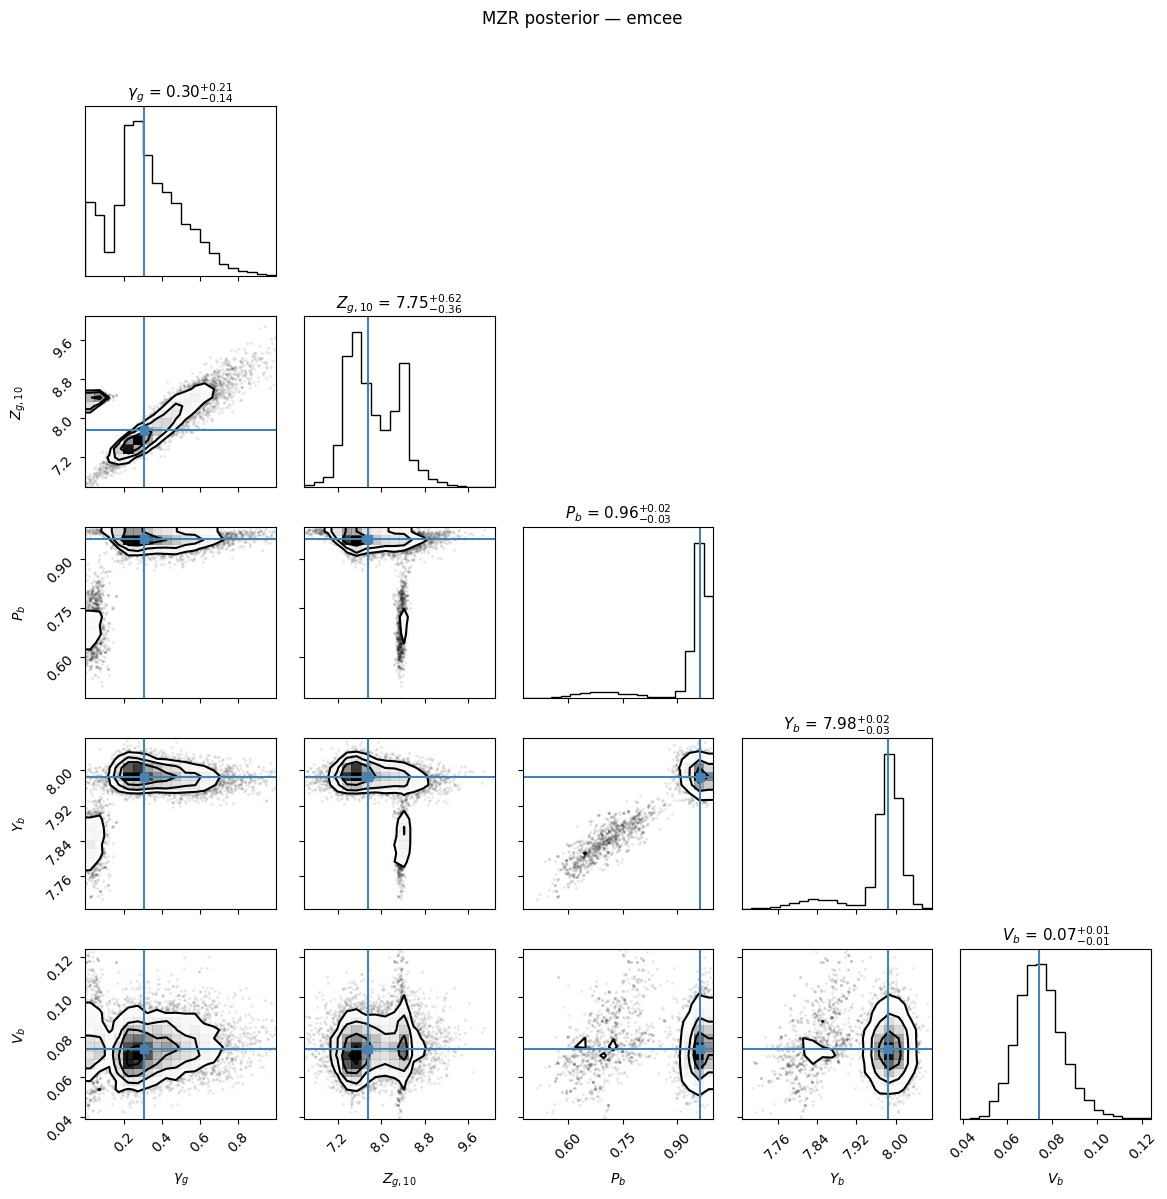

In [10]:
"""
Bayesian fitting of the Mass-Metallicity Relation (MZR) using emcee.

Model (Equation 2):
    12 + log(O/H) = gamma_g * [log(M_star/M_sun) - 10] + Z_g10

Two modes:
    A) No outlier rejection   -> ln_likelihood_normal  (2 parameters)
    B) Outlier-robust fitting -> log_probability_prune (5 parameters)
       q_i are marginalised analytically, NOT sampled, to keep the
       problem low-dimensional.
"""

import numpy as np
import pandas as pd
import emcee
import corner
import matplotlib.pyplot as plt
from scipy.special import logsumexp


# ---------------------------------------------------------------------------
# 1.  Load data
# ---------------------------------------------------------------------------
try:
    df = pd.read_csv("MW_PEAS.csv")
except FileNotFoundError:
    print("Error: MW_PEAS.csv not found. Please ensure the data file is in the correct directory.")
    exit()

mask = (df['STELLAR_MASS'].values > 0) & (df["Z_dir_gen"] > 0) & (df["Z_dir_gen_err"] > 1e-5)

log_mass = df["STELLAR_MASS"].values[mask]           # log10(M*/Msun)
mass_err = 0.1 * df["STELLAR_MASS"].values[mask]      # uncertainty on log_mass
log_OH = df["Z_dir_gen"].values[mask]             # 12 + log(O/H)  measured
OH_err_up = 7 * df["Z_dir_gen_err"].values[mask]        # upper metallicity uncertainty
OH_err_lo = 7 * df["Z_dir_gen_err"].values[mask]        # lower metallicity uncertainty

N = len(log_mass)

# Number of mass draws per galaxy per likelihood call.
# Increase for more accurate marginalisation (slower); 20 is a good default.
N_MASS_DRAWS = 100


# ---------------------------------------------------------------------------
# 2.  MZR model
# ---------------------------------------------------------------------------
def model_OH(log_mass_draw, gamma_g, Z_g10):
    """Eq. 2:  predicted 12+log(O/H) given log stellar mass."""
    return gamma_g * (log_mass_draw - 10.0) + Z_g10


# ---------------------------------------------------------------------------
# 3.  Split-normal sigma (Eq. A2)
# ---------------------------------------------------------------------------
def sigma_i(OH_model, OH_truth, err_up, err_lo):
    return np.where(OH_model >= OH_truth, err_up, err_lo)


# ---------------------------------------------------------------------------
# 4.  Averaged log-likelihood over mass draws
# ---------------------------------------------------------------------------
def _mass_averaged_terms(gamma_g, Z_g10):
    mass_draws = np.random.normal(log_mass, mass_err,
                                  size=(N_MASS_DRAWS, N))
    OH_model = model_OH(mass_draws, gamma_g, Z_g10)
    sig = sigma_i(OH_model, log_OH, OH_err_up, OH_err_lo)
    sig2 = sig ** 2

    ln_inlier_draws = (
        -0.5 * np.log(2.0 * np.pi * sig2)
        - 0.5 * ((log_OH - OH_model) ** 2) / sig2
    )
    ln_inlier = logsumexp(ln_inlier_draws, axis=0) - np.log(N_MASS_DRAWS)
    mean_sig2 = np.mean(sig2, axis=0)
    return ln_inlier, mean_sig2


# ---------------------------------------------------------------------------
# 5a.  Mode A: no outlier rejection (log-likelihood)
# ---------------------------------------------------------------------------
def ln_likelihood_normal(theta):
    gamma_g, Z_g10 = theta
    ln_inlier, _ = _mass_averaged_terms(gamma_g, Z_g10)
    return float(np.sum(ln_inlier))


# ---------------------------------------------------------------------------
# 5b.  Mode B: outlier-robust (log-likelihood)
# ---------------------------------------------------------------------------
def ln_likelihood_prune(theta):
    """
    The total likelihood is (1-P_b)*p(data|inlier) + P_b*p(data|outlier).
    The log-likelihood is logsumexp([A, B]) where:
        A = ln p(data|inlier) + ln(1 - P_b)
        B = ln p(data|outlier) + ln(P_b)
    """
    gamma_g, Z_g10, P_b, Y_b, V_b = theta

    ln_inlier, mean_sig2 = _mass_averaged_terms(gamma_g, Z_g10)

    V_eff = V_b + mean_sig2
    ln_outlier = (
        -0.5 * np.log(2.0 * np.pi * V_eff)
        - 0.5 * ((log_OH - Y_b) ** 2) / V_eff
    )

    A = ln_inlier + np.log(1.0 - P_b)
    B = ln_outlier + np.log(P_b)
    ln_marg = logsumexp(np.stack([A, B], axis=0), axis=0)

    return float(np.sum(ln_marg))


# ---------------------------------------------------------------------------
# 6.  Priors and Log-probability
# ---------------------------------------------------------------------------
# These prior transform functions are from the original dynesty script.
# We can use them to initialize the walkers in emcee.
def prior_transform_normal(u):
    return np.array([3.0 * u[0], 6.0 + 3.0 * u[1]])

def prior_transform_prune(u):
    epsilon = 1e-5
    gamma_g = 1.0 * u[0]
    Z_g10   = 6.0 + 5.0 * u[1]
    P_b     = (1.0 - 2.0 * epsilon) * u[2] + epsilon
    Y_b     = 6.0 + 3.0 * u[3]
    log_Vb_min = -3.0
    log_Vb_max = np.log10(4.0)
    V_b = 10**((log_Vb_max - log_Vb_min) * u[4] + log_Vb_min)
    return np.array([gamma_g, Z_g10, P_b, Y_b, V_b])

# New log-prior functions for emcee
def log_prior_prune(theta):
    gamma_g, Z_g10, P_b, Y_b, V_b = theta
    epsilon = 1e-5
    log_Vb_min = -3.0
    log_Vb_max = np.log10(4.0)

    # Check bounds for flat priors
    if not (0.0 < gamma_g < 1.0): return -np.inf
    if not (6.0 < Z_g10 < 11.0): return -np.inf
    if not (epsilon < P_b < 1.0 - epsilon): return -np.inf
    if not (6.0 < Y_b < 9.0): return -np.inf
    # Check bounds for log-uniform prior
    if not (10**log_Vb_min < V_b < 10**log_Vb_max): return -np.inf

    # The log-prior for a log-uniform distribution p(x) ~ 1/x is log(p(x)) ~ -log(x)
    return -np.log(V_b)

def log_probability_prune(theta):
    lp = log_prior_prune(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = ln_likelihood_prune(theta)
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll

# --- For Mode A (no outliers) ---
def log_prior_normal(theta):
    gamma_g, Z_g10 = theta
    if not (0.0 < gamma_g < 3.0): return -np.inf
    if not (6.0 < Z_g10 < 9.0): return -np.inf
    return 0.0

def log_probability_normal(theta):
    lp = log_prior_normal(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + ln_likelihood_normal(theta)


# ---------------------------------------------------------------------------
# 7.  Run MCMC Sampling
# ---------------------------------------------------------------------------
OUTLIER_MODE = True

if not OUTLIER_MODE:
    ndim, log_prob, prior_transform = 2, log_probability_normal, prior_transform_normal
    param_labels = [r"$\gamma_g$", r"$Z_{g,10}$"]
else:
    ndim, log_prob, prior_transform = 5, log_probability_prune, prior_transform_prune
    param_labels = [r"$\gamma_g$", r"$Z_{g,10}$", r"$P_b$", r"$Y_b$", r"$V_b$"]

# MCMC parameters
nwalkers = 50
nsteps = 4000
nburn = 1000

# Initialize walkers by sampling from the prior
initial_state = np.array([prior_transform(np.random.rand(ndim)) for _ in range(nwalkers)])

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)

print("Running MCMC...")
sampler.run_mcmc(initial_state, nsteps, progress=True)
print("MCMC complete.")

# Get samples, discarding burn-in and thinning
samples = sampler.get_chain(discard=nburn, thin=15, flat=True)


# ---------------------------------------------------------------------------
# 8.  Extract best-fit parameters
# ---------------------------------------------------------------------------
print("\nParameter estimates:")
for i, label in enumerate(param_labels):
    lo, med, hi = np.percentile(samples[:, i], [16, 50, 84])
    print(f"{label:>12s}  =  {med:.3f}  +{hi-med:.3f} / -{med-lo:.3f}")


# ---------------------------------------------------------------------------
# 9.  Infer per-galaxy outlier probabilities (Mode B only)
# ---------------------------------------------------------------------------
if OUTLIER_MODE:
    # Get the median parameter values from the posterior
    best_params = np.median(samples, axis=0)
    gamma_g_best, Z_g10_best, P_b_best, Y_b_best, V_b_best = best_params

    ln_inlier, mean_sig2 = _mass_averaged_terms(gamma_g_best, Z_g10_best)
    V_eff = V_b_best + mean_sig2
    ln_outlier = (
        -0.5 * np.log(2.0 * np.pi * V_eff)
        - 0.5 * ((log_OH - Y_b_best) ** 2) / V_eff
    )

    # Posterior probability of being an inlier (q_i) via Bayes' theorem:
    # p(inlier|data) = p(data|inlier)p(inlier) / p(data)
    # log(p(inlier|data)) = log(p(data|inlier)) + log(1-P_b) - log(p(data))
    A = ln_inlier + np.log(1.0 - P_b_best)
    B = ln_outlier + np.log(P_b_best)
    log_norm = logsumexp(np.stack([A, B], axis=0), axis=0)
    q_best = np.exp(A - log_norm)

    df_masked = df[mask].copy()
    df_masked["q_inlier"] = q_best

    print("\nGalaxies with q_inlier < 0.5 (likely outliers):")
    print(df_masked[df_masked["q_inlier"] < 0.5][["STELLAR_MASS", "Z_dir_gen", "q_inlier"]])


# ---------------------------------------------------------------------------
# 10.  Diagnostic plots
# ---------------------------------------------------------------------------
fig = corner.corner(
    samples, labels=param_labels, truths=np.median(samples, axis=0),
    show_titles=True, title_kwargs={"fontsize": 11}
)
plt.suptitle("MZR posterior — emcee", y=1.02)
plt.tight_layout()
plt.savefig("mzr_corner_emcee.pdf", bbox_inches="tight")
plt.show()
